# 02 Data Preprocessing

This notebook cleans the combined parking transaction dataset and prepares two outputs: a cleaned transaction-level file for later analysis, and a daily site-level aggregate. Steps include datetime parsing, duration derivation, duplicate removal, handling of high-missing columns and invalid durations, calendar feature engineering, and column selection.

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Combine Raw Site Files

In [ ]:
base_path = r"data/processed/parking_transactions_cleaned.csv"

site_a = pd.read_csv(f"{base_path}/siteA_transaction_2025.csv", na_values=["\\N"])
site_b = pd.read_csv(f"{base_path}/siteB_Transaction_2025.csv", na_values=["\\N"])
site_c = pd.read_csv(f"{base_path}/siteC_Transacation_2025.csv", na_values=["\\N"])

site_a["site"] = "Site A"
site_b["site"] = "Site B"
site_c["site"] = "Site C"

df = pd.concat([site_a, site_b, site_c], ignore_index=True)

df.shape

(87441, 22)

## Parse Datetime Columns

In [10]:
df["transaction_dateIn"] = pd.to_datetime(df["transaction_dateIn"], errors="coerce")
df["transaction_dateOut"] = pd.to_datetime(df["transaction_dateOut"], errors="coerce")
df["ss_sync_date"] = pd.to_datetime(df["ss_sync_date"], errors="coerce")
df["hq_sync_date"] = pd.to_datetime(df["hq_sync_date"], errors="coerce")

## Derive Parking Duration

In [11]:
df["parking_duration_minutes"] = (
    (df["transaction_dateOut"] - df["transaction_dateIn"]).dt.total_seconds() / 60
)

df["parking_duration_minutes"].describe()

count    87441.000000
mean       567.561090
std       1154.841381
min         -3.216667
25%        156.816667
50%        517.450000
75%        723.183333
max      90143.666667
Name: parking_duration_minutes, dtype: float64

## Missing Value Summary

In [12]:
before_rows = len(df)
df = df.drop_duplicates()
after_rows = len(df)

print("Rows before duplicate removal:", before_rows)
print("Rows after duplicate removal:", after_rows)
print("Duplicate rows removed:", before_rows - after_rows)

Rows before duplicate removal: 87441
Rows after duplicate removal: 87441
Duplicate rows removed: 0


## Drop Columns With Excessive Missingness

In [13]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
sst_amount,87441,100.000000
coupon_id,87441,100.000000
RRN,80795,92.399446
STAN,80795,92.399446
approval_code,80795,92.399446
response_code,80758,92.357132
device_id_in,51832,59.276541
card_type,1,0.001144
sync_flag,0,0.000000
site,0,0.000000


In [14]:

high_missing_cols = missing_summary[missing_summary["Missing Percentage"] > 50].index.tolist()
high_missing_cols


['sst_amount',
 'coupon_id',
 'RRN',
 'STAN',
 'approval_code',
 'response_code',
 'device_id_in']

In [15]:

df_reduced = df.drop(columns=high_missing_cols)
df_reduced.shape


(87441, 16)

## Handle Invalid (Negative) Durations

In [16]:

negative_duration_count = (df_reduced["parking_duration_minutes"] < 0).sum()
print("Negative duration count:", negative_duration_count)


Negative duration count: 1


In [17]:
before_rows = len(df_reduced)

df_reduced = df_reduced[
    (df_reduced["parking_duration_minutes"].isna()) |
    (df_reduced["parking_duration_minutes"] >= 0)
]

after_rows = len(df_reduced)

print("Rows before removing negative duration:", before_rows)
print("Rows after removing negative duration:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removing negative duration: 87441
Rows after removing negative duration: 87440
Rows removed: 1


In [18]:

df_reduced["parking_duration_minutes"].describe(percentiles=[0.90, 0.95, 0.99])


count    87440.000000
mean       567.567618
std       1154.846371
min          0.166667
50%        517.450000
90%        915.051667
95%       1005.910000
99%       4343.658000
max      90143.666667
Name: parking_duration_minutes, dtype: float64

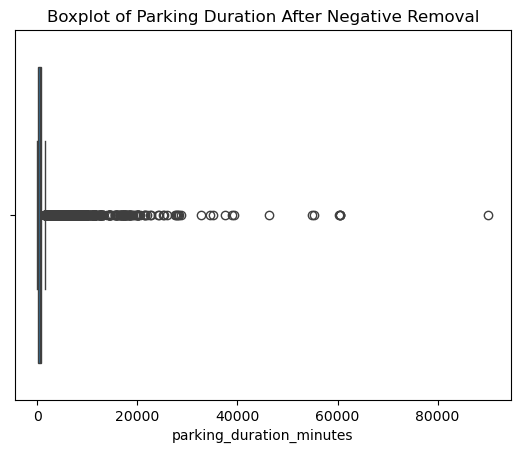

In [19]:
sns.boxplot(x=df_reduced["parking_duration_minutes"])
plt.title("Boxplot of Parking Duration After Negative Removal")
plt.show()

## Engineer Calendar Features

In [ ]:


df_reduced["entry_date"] = df_reduced["transaction_dateIn"].dt.date
df_reduced["entry_year"] = df_reduced["transaction_dateIn"].dt.year
df_reduced["entry_month"] = df_reduced["transaction_dateIn"].dt.month
df_reduced["entry_day"] = df_reduced["transaction_dateIn"].dt.day
df_reduced["entry_hour"] = df_reduced["transaction_dateIn"].dt.hour
df_reduced["entry_day_name"] = df_reduced["transaction_dateIn"].dt.day_name()
df_reduced["entry_dayofweek_num"] = df_reduced["transaction_dateIn"].dt.dayofweek
df_reduced["is_weekend"] = df_reduced["entry_dayofweek_num"].isin([5, 6]).astype(int)
df_reduced["exit_hour"] = df_reduced["transaction_dateOut"].dt.hour
df_reduced["is_paid"] = (df_reduced["amount"] > 0).astype(int)
df_reduced["amount"] = pd.to_numeric(df_reduced["amount"], errors="coerce")



## Select Final Columns

In [22]:
selected_cols = [
    "id", "loc_id", "reference_id",
    "transaction_dateIn", "transaction_dateOut",
    "card_no", "amount", "card_type",
    "batch_id", "user_category", "site",
    "parking_duration_minutes",
    "entry_date", "entry_year", "entry_month",
    "entry_day", "entry_hour", "entry_day_name",
    "entry_dayofweek_num", "is_weekend",
    "exit_hour", "is_paid"
]

selected_cols = [col for col in selected_cols if col in df_reduced.columns]
df_final = df_reduced[selected_cols].copy()

df_final.head()


,id,loc_id,reference_id,transaction_dateIn,transaction_dateOut,card_no,amount,card_type,batch_id,user_category,...,entry_date,entry_year,entry_month,entry_day,entry_hour,entry_day_name,entry_dayofweek_num,is_weekend,exit_hour,is_paid
0,43525,42,42202511756075005,2025-01-01 07:48:30,2025-01-01 07:55:26,2783752655,0.0,TNG,488,1,...,2025-01-01,2025,1,1,7,Wednesday,2,0,7,0
1,43530,42,422025111449019504,2025-01-01 14:41:08,2025-01-01 14:42:48,1882361935,0.0,TNG,488,1,...,2025-01-01,2025,1,1,14,Wednesday,2,0,14,0
2,43531,42,422025111514034412,2025-01-01 14:38:23,2025-01-01 15:10:48,2165653295,0.0,TNG,488,1,...,2025-01-01,2025,1,1,14,Wednesday,2,0,15,0
3,43532,42,422025111521010598,2025-01-01 10:16:10,2025-01-01 15:20:36,2783752655,10.0,TNG,488,1,...,2025-01-01,2025,1,1,10,Wednesday,2,0,15,1
4,43533,42,42202511177047676,2025-01-01 16:36:45,2025-01-01 17:03:01,1795549711,0.0,TNG,488,1,...,2025-01-01,2025,1,1,16,Wednesday,2,0,17,0


In [23]:

df_final.info()


<class 'pandas.core.frame.DataFrame'>
Index: 87440 entries, 0 to 87440
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        87440 non-null  int64         
 1   loc_id                    87440 non-null  int64         
 2   reference_id              87440 non-null  object        
 3   transaction_dateIn        87440 non-null  datetime64[ns]
 4   transaction_dateOut       87440 non-null  datetime64[ns]
 5   card_no                   87440 non-null  object        
 6   amount                    87440 non-null  float64       
 7   card_type                 87439 non-null  object        
 8   batch_id                  87440 non-null  int64         
 9   user_category             87440 non-null  int64         
 10  site                      87440 non-null  object        
 11  parking_duration_minutes  87440 non-null  float64       
 12  entry_date             

## Save Cleaned Transaction-Level Dataset

In [25]:

output_path = r"C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\data\processed"

df_final.to_csv(f"{output_path}/parking_transactions_cleaned.csv", index=False)

print("Cleaned transaction-level dataset saved successfully.")


Cleaned transaction-level dataset saved successfully.


## Build Daily Site-Level Aggregate

In [26]:
daily_df = (
    df_final.groupby(["site", "entry_date"])
    .agg(
        daily_transactions=("id", "count"),
        avg_duration_minutes=("parking_duration_minutes", "mean"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

daily_df.head()

,site,entry_date,daily_transactions,avg_duration_minutes,total_amount
0,Site A,2025-01-01,11,183.286364,37.0
1,Site A,2025-01-02,32,196.616146,152.0
2,Site A,2025-01-03,41,177.115041,153.0
3,Site A,2025-01-04,13,239.711538,46.0
4,Site A,2025-01-05,18,153.541667,60.0


In [28]:
# ---- Duration tail diagnostic (read-only, changes nothing) ----

dur = df["parking_duration_minutes"]

# 1. Full distribution
print("=== Distribution ===")
print(dur.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(1))
print("Max (minutes):", round(dur.max(), 1), "| in days:", round(dur.max()/1440, 1))
print()

# 2. What fraction sits above each threshold?
print("=== Fraction of records above each duration ===")
for h in [4, 8, 12, 24, 48]:
    pct = (dur > h * 60).mean() * 100
    n   = (dur > h * 60).sum()
    print(f"> {h:>2}h : {pct:5.2f}%   ({n} records)")
print()

# 3. Do the very long stays actually pay? (real long-parkers usually pay; ghost logs often don't)
print("=== Payment behaviour: long stays (>24h) vs normal ===")
tmp = df.copy()
tmp["is_long"] = tmp["parking_duration_minutes"] > 24 * 60
summary = tmp.groupby("is_long")["amount"].agg(
    count="count",
    mean_amount="mean",
    median_amount="median",
    pct_zero_paid=lambda x: (x == 0).mean() * 100,
).round(2)
print(summary)
print()

# 4. Are the long stays concentrated at one site?
print("=== Median duration by site (minutes) ===")
print(df.groupby("site")["parking_duration_minutes"].median().round(1))

=== Distribution ===
count    87441.0
mean       567.6
std       1154.8
min         -3.2
25%        156.8
50%        517.4
75%        723.2
90%        915.0
95%       1005.9
99%       4343.6
max      90143.7
Name: parking_duration_minutes, dtype: float64
Max (minutes): 90143.7 | in days: 62.6

=== Fraction of records above each duration ===
>  4h : 65.93%   (57650 records)
>  8h : 52.39%   (45806 records)
> 12h : 25.22%   (22049 records)
> 24h :  2.55%   (2227 records)
> 48h :  1.48%   (1292 records)

=== Payment behaviour: long stays (>24h) vs normal ===
         count  mean_amount  median_amount  pct_zero_paid
is_long                                                  
False    85214         5.95            4.0          42.10
True      2227        28.60           24.0          29.28

=== Median duration by site (minutes) ===
site
Site A    123.1
Site B    452.9
Site C    773.3
Name: parking_duration_minutes, dtype: float64
